In [64]:
!pip install rouge_score
!pip install -q "huggingface_hub==0.21.0"

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.model_selection import train_test_split
from rouge_score import rouge_scorer
from pathlib import Path

In [67]:
import shutil
import os

os.makedirs("/content/prompt_predictor", exist_ok=True)
shutil.copytree(
    "/content/drive/MyDrive/prompt_predictor",
    "/content/prompt_predictor",
    dirs_exist_ok=True
)

'/content/prompt_predictor'

In [68]:
SAVE_PATH = "/content/prompt_predictor"
CONTEXT_CSV = "prompt_answer_pairs_context.csv"
OUTPUT_CSV  = "conv_index_rouge_results.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Data

In [69]:
df = pd.read_csv(CONTEXT_CSV)[["context_input", "prompt", "answer", "conv_index"]].dropna()

df["prompt"] = df["prompt"].astype(str).str.strip()
df["answer"] = df["answer"].astype(str).str.strip()
df["context_input"] = df["context_input"].astype(str).str.strip()

# 70/15/15 split
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Test set size: {len(test_df)} rows")
print(f"conv_index distribution in test set:")
print(test_df["conv_index"].value_counts().sort_index())

Test set size: 599 rows
conv_index distribution in test set:
conv_index
0      145
1       89
2       75
3       62
4       25
5       30
6       22
7       23
8       16
9       14
10      12
11       8
12       6
13       5
14       5
15       7
16       7
17       4
18       1
19       5
20       3
21       5
22       2
23       2
24       2
25       1
26       1
27       1
28       3
29       1
30       3
31       1
32       1
37       1
42       1
45       1
61       1
157      1
178      1
195      1
205      1
207      1
214      1
260      1
261      1
Name: count, dtype: int64


### Load Model and Tokenizer

In [70]:
tokenizer = T5Tokenizer.from_pretrained(SAVE_PATH)
model     = T5ForConditionalGeneration.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

### Run Predictions

Track conv_index for every row

In [71]:
results = []

for i, (_, row) in enumerate(test_df.iterrows()):
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(test_df)}")

    inputs = tokenizer(
        row["context_input"],
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=128,
            num_beams=4,
            early_stopping=True
        )

    predicted = tokenizer.decode(output[0], skip_special_tokens=True)
    scores    = scorer.score(row["prompt"], predicted)

    results.append({
        "conv_index": int(row["conv_index"]),
        "reference":  row["prompt"],
        "prediction": predicted,
        "answer":     row["answer"],
        "rouge1":     scores["rouge1"].fmeasure,
        "rouge2":     scores["rouge2"].fmeasure,
        "rougeL":     scores["rougeL"].fmeasure,
    })

# Save predictions to conv_index_rouge_results.csv
results_df = pd.DataFrame(results)
results_df = results_df[results_df["conv_index"] <= 10]
print(f"Rows after capping at conv_index 10: {len(results_df)}")
results_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

  100/599
  200/599
  300/599
  400/599
  500/599
Rows after capping at conv_index 10: 513


### Aggregate ROUGE by conv_index

In [72]:
grouped = (
    results_df
    .groupby("conv_index")[["rouge1", "rouge2", "rougeL"]]
    .agg(["mean", "std", "count"])
    .round(4)
)

print("\n--- Average ROUGE Scores by conv_index ---")
print(grouped.to_string())

# Flat version for plotting
grouped_mean = (
    results_df
    .groupby("conv_index")[["rouge1", "rouge2", "rougeL"]]
    .mean()
    .reset_index()
)


--- Average ROUGE Scores by conv_index ---
            rouge1                rouge2                rougeL              
              mean     std count    mean     std count    mean     std count
conv_index                                                                  
0           0.4540  0.2630   145  0.2939  0.2759   145  0.4049  0.2660   145
1           0.3126  0.2071    89  0.1274  0.1680    89  0.2761  0.1989    89
2           0.2419  0.1955    75  0.1015  0.1478    75  0.2124  0.1834    75
3           0.2340  0.2177    62  0.0969  0.1995    62  0.2098  0.2136    62
4           0.2290  0.1539    25  0.0669  0.1289    25  0.1978  0.1376    25
5           0.2653  0.2211    30  0.1175  0.1604    30  0.2263  0.1867    30
6           0.1855  0.2106    22  0.0856  0.2196    22  0.1727  0.2116    22
7           0.2381  0.1538    23  0.0838  0.1350    23  0.2057  0.1390    23
8           0.2978  0.2343    16  0.1260  0.2037    16  0.2448  0.2246    16
9           0.2110  0.2020    14

### Pearson Correlation

The Pearson correlation gives you a single number between -1 and 1 that summarizes the relationship between conv_index and ROUGE score.

In [73]:
corr_r1 = results_df["conv_index"].corr(results_df["rouge1"])
corr_r2 = results_df["conv_index"].corr(results_df["rouge2"])
corr_rL = results_df["conv_index"].corr(results_df["rougeL"])

print(f"  ROUGE-1:  {corr_r1:.4f}")
print(f"  ROUGE-2:  {corr_r2:.4f}")
print(f"  ROUGE-L:  {corr_rL:.4f}")

  ROUGE-1:  -0.2814
  ROUGE-2:  -0.2650
  ROUGE-L:  -0.2774


Negative = as conv_index increases, ROUGE goes down. More missing context = worse predictions. Later in a conversation are harder to predict.

This might be happening because...

*   Early turns are simpler

*   The context window gets noisy: model only uses the last 2 prior turns. At higher indexes the conversation may have drifted in topic, making the prior 2 turns less useful as context.

### Plots

#### Line plot — mean ROUGE per conv_index

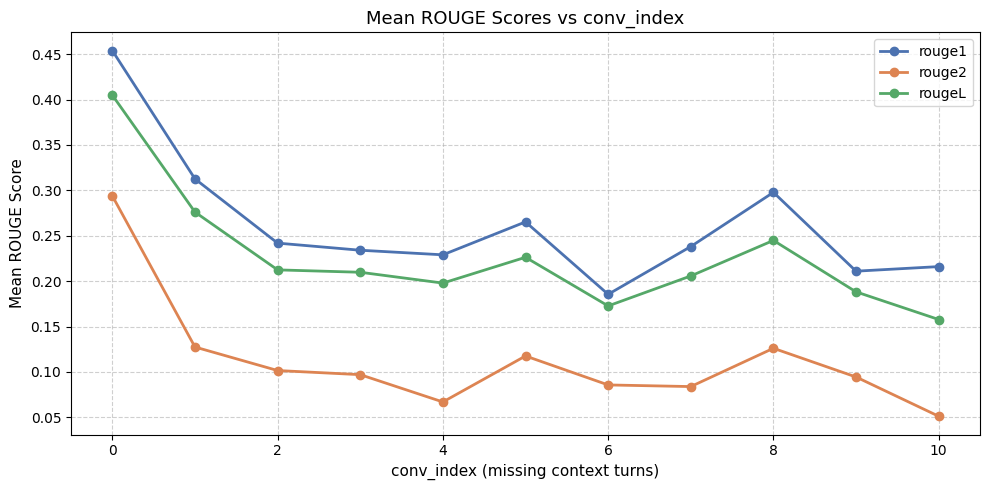

In [74]:
fig, ax = plt.subplots(figsize=(10, 5))
for metric, color in [("rouge1", "#4C72B0"), ("rouge2", "#DD8452"), ("rougeL", "#55A868")]:
    ax.plot(
        grouped_mean["conv_index"],
        grouped_mean[metric],
        marker="o",
        label=metric,
        color=color,
        linewidth=2
    )
ax.set_title("Mean ROUGE Scores vs conv_index", fontsize=13)
ax.set_xlabel("conv_index (missing context turns)", fontsize=11)
ax.set_ylabel("Mean ROUGE Score", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("rouge_vs_conv_index_line.png", dpi=150)
plt.show()

#### Plot 2: Box plot — ROUGE-L distribution per conv_index

/tmp/ipykernel_468/2843061916.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


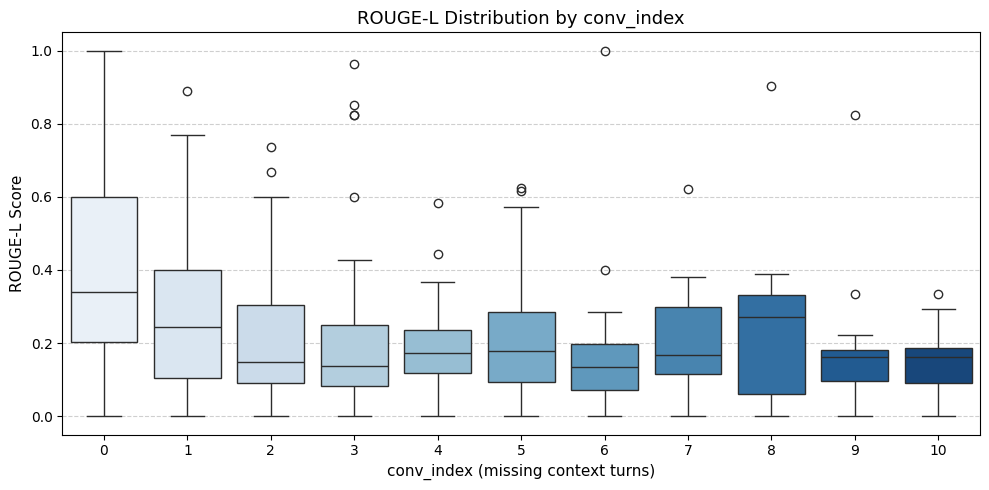

In [79]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    x="conv_index",
    y="rougeL",
    data=results_df,
    palette="Blues",
    ax=ax
)
ax.set_title("ROUGE-L Distribution by conv_index", fontsize=13)
ax.set_xlabel("conv_index (missing context turns)", fontsize=11)
ax.set_ylabel("ROUGE-L Score", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("rougeL_boxplot_conv_index.png", dpi=150)
plt.show()

#### Plot 3: Bar chart with error bars

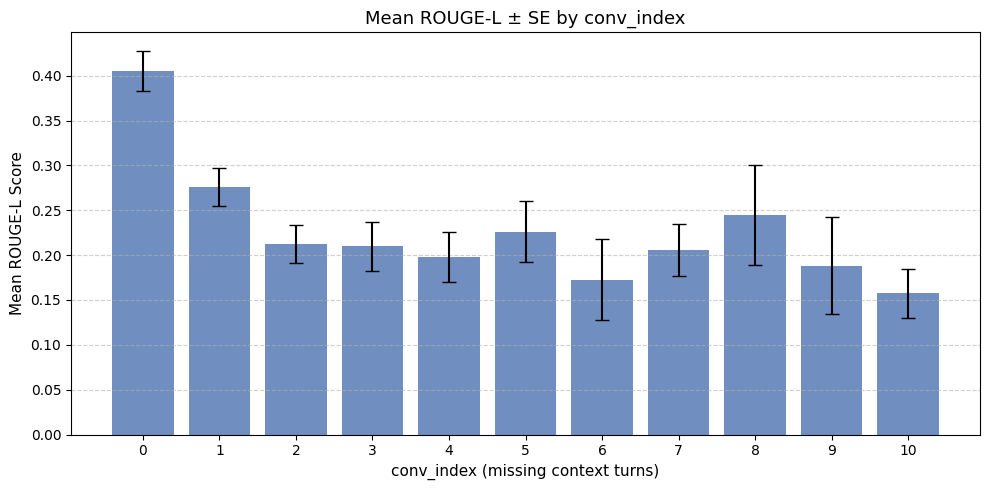

In [76]:
grouped_stats = (
    results_df
    .groupby("conv_index")["rougeL"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
grouped_stats["se"] = grouped_stats["std"] / np.sqrt(grouped_stats["count"])  # standard error

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    grouped_stats["conv_index"],
    grouped_stats["mean"],
    yerr=grouped_stats["se"],
    capsize=5,
    color="#4C72B0",
    alpha=0.8,
    error_kw={"elinewidth": 1.5}
)
ax.set_title("Mean ROUGE-L ± SE by conv_index", fontsize=13)
ax.set_xlabel("conv_index (missing context turns)", fontsize=11)
ax.set_ylabel("Mean ROUGE-L Score", fontsize=11)
ax.set_xticks(grouped_stats["conv_index"])
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("rougeL_bar_conv_index.png", dpi=150)
plt.show()

#### Plot 4: Scatter — conv_index vs ROUGE-L (jittered)

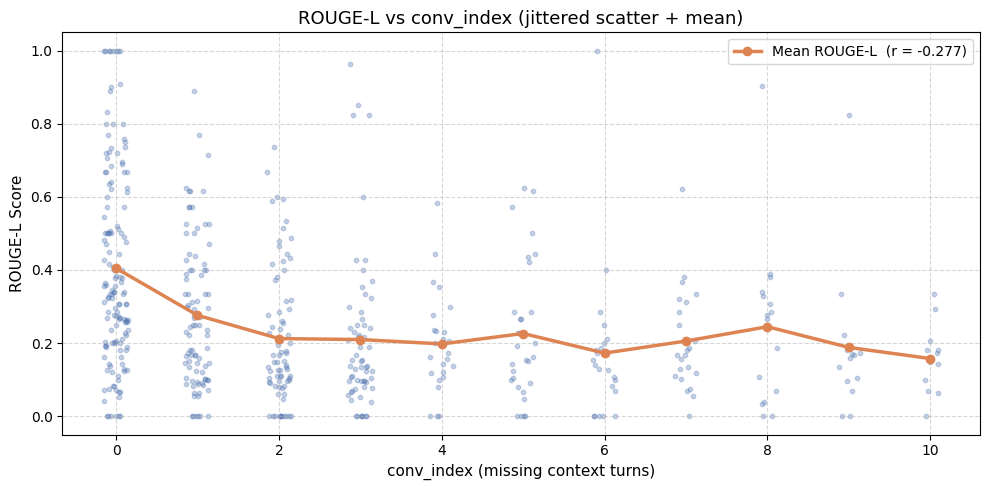

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))
jitter = np.random.uniform(-0.15, 0.15, size=len(results_df))
ax.scatter(
    results_df["conv_index"] + jitter,
    results_df["rougeL"],
    alpha=0.3,
    s=10,
    color="#4C72B0"
)
# Overlay the mean line
ax.plot(
    grouped_mean["conv_index"],
    grouped_mean["rougeL"],
    color="#DD8452",
    linewidth=2.5,
    marker="o",
    label=f"Mean ROUGE-L  (r = {corr_rL:.3f})"
)
ax.set_title("ROUGE-L vs conv_index (jittered scatter + mean)", fontsize=13)
ax.set_xlabel("conv_index (missing context turns)", fontsize=11)
ax.set_ylabel("ROUGE-L Score", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("rougeL_scatter_conv_index.png", dpi=150)
plt.show()

### Sample predictions per conv_index bucket

In [78]:
for idx in sorted(results_df["conv_index"].unique()):
    subset = results_df[results_df["conv_index"] == idx]
    # Pick the row closest to the mean ROUGE-L for that bucket
    mean_score = subset["rougeL"].mean()
    sample = subset.iloc[(subset["rougeL"] - mean_score).abs().argsort()[:1].iloc[0]]
    print(f"\nconv_index = {idx}  (n={len(subset)}, mean ROUGE-L={mean_score:.4f})")
    print(f"  Reference:  {sample['reference']}")
    print(f"  Prediction: {sample['prediction']}")
    print(f"  ROUGE-L:    {sample['rougeL']:.4f}")


conv_index = 0  (n=145, mean ROUGE-L=0.4049)
  Reference:  promise.then()中，我理解then会等到前面的promise settle完成，才会进行下一步。我想知道then中直接return，和return一个promise的区别是什么？ 即 promise.then(new Promise)
  Prediction:  promise.then()  Promise  JavaScript Promise Promise  then()  Promise resolve Promise reject promise.then()  Promise  then() [CODE_BLOCK_0] then()  "Hello"  Promise  then()  then()  Promise  then()  Promise  settled[CODE_BLOCK_1] then() 
  ROUGE-L:    0.4091

conv_index = 1  (n=89, mean ROUGE-L=0.2761)
  Reference:  So, if the "employee position title" is "Firefighter/Rescuer III", what does having "Firefighter/Rescuer I (Recruit)" as the "underfilled job title" mean?
  Prediction: What is an "underfilled job title"?
  ROUGE-L:    0.2759

conv_index = 2  (n=75, mean ROUGE-L=0.2124)
  Reference:  But won't the query be slower than a materialized view? Answer in a few words
  Prediction: How to have fast query times using a view, streams and Tasks
  ROUGE-L:    0.2143

conv_index = 3  (n=62, m